In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from VERSUS import SphericalVoids, setup_logging

In [3]:
cellsize = 7  # set cellsize used for void-finding

setup_logging()

pos = np.load("density_profile/c000_ph000_hod001_positions.npy")

# Cubic simulation data 

In [4]:
sv = SphericalVoids(data_positions=pos, cellsize=cellsize, 
                    boxsize=[2000,2000,2000], boxcenter=[0,0,0])
sv.run_voidfinding()

16:40:40 | INFO | meshbuilder.py | __init__ | Ln55 | Loading box-like data
16:40:40 | INFO | meshbuilder.py | size_mesh | Ln296 | Estimating volume and average galaxy separation (Ngal = 3999058)
16:40:41 | INFO | meshbuilder.py | create_mesh | Ln367 | Estimating mesh density (nmesh=[284 284 284])
16:40:43 | INFO | meshbuilder.py | _set_mesh_density | Ln211 | Applying initial smoothing of R=3.5 Mpc/h to the density field
16:40:43 | INFO | 2641124399.py | <module> | Ln1 | Making k-d trees
16:40:44 | INFO | 2641124399.py | <module> | Ln3 | Running spherical void-finder with 8 threads (delta < -0.80)
16:40:45 | INFO | 2641124399.py | <module> | Ln3 | No cells with delta < -0.80 for R=60.0 Mpc/h
16:40:46 | INFO | 2641124399.py | <module> | Ln3 | No cells with delta < -0.80 for R=58.0 Mpc/h
16:40:46 | INFO | 2641124399.py | <module> | Ln3 | No cells with delta < -0.80 for R=56.0 Mpc/h
16:40:47 | INFO | 2641124399.py | <module> | Ln3 | Found 4 voids with radius R=54.0 Mpc/h
16:40:48 | INFO | 

Analyse the void-finding outputs.

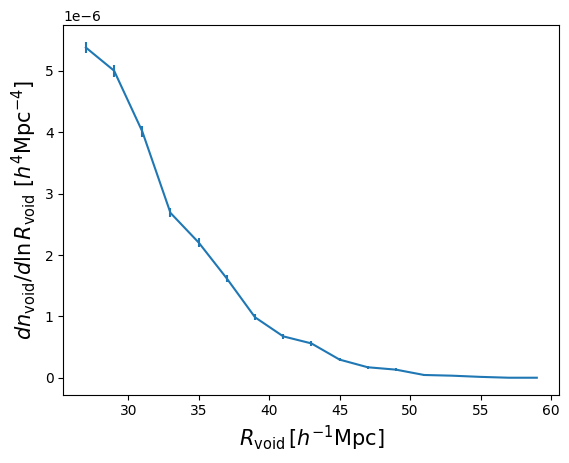

In [5]:
vsf_ax = sv.plot_size_function(label='full box')

# Mock survey data

Cut out a non-cubic portion of the box and provide random positions to estimate the geometry.

In [6]:
L = 1000          # box length of portion
rand_factor = 50  # number of random positions to generate

# cut box positions
pos_small = pos[(pos > 0).all(axis=1) & (pos < L).all(axis=1)]
del pos

# generate randoms
randoms = np.random.random((rand_factor * pos_small.shape[0], 3)) * L

# slice portion of the cube in half
randoms = randoms[randoms[:,2] / randoms[:,1]<=1]
pos_small = pos_small[pos_small[:,2] / pos_small[:,1]<=1]
# save true values for comparison
cutout_vol_true = 1000**3 / 2
cutout_rho_true = pos_small.shape[0] / cutout_vol_true

Plot the cutout data positions.

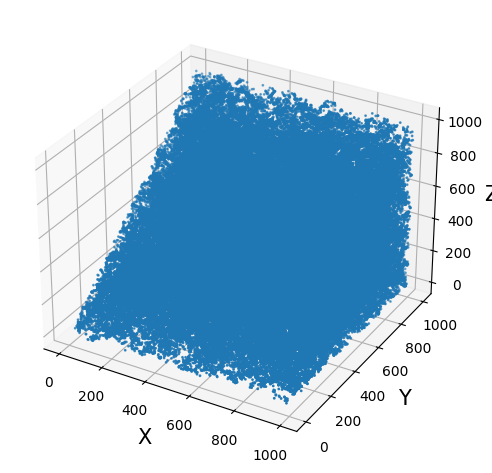

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(*pos_small.transpose(), s=1)
ax.set_xlabel('X', fontsize=15);
ax.set_ylabel('Y', fontsize=15);
ax.set_zlabel('Z', fontsize=15);
plt.tight_layout()

Run void-finding on cutout.

In [8]:
sv = SphericalVoids(data_positions=pos_small, 
                    random_positions=randoms,
                    cellsize=cellsize)
sv.run_voidfinding()

16:41:21 | INFO | meshbuilder.py | __init__ | Ln55 | Loading survey-like data
16:41:21 | INFO | meshbuilder.py | size_mesh | Ln296 | Estimating volume and average galaxy separation (Ngal = 253110)
16:41:35 | INFO | meshbuilder.py | create_mesh | Ln367 | Estimating mesh density (nmesh=[158 158 158])
16:41:39 | INFO | meshbuilder.py | _set_mesh_density | Ln211 | Applying initial smoothing of R=3.5 Mpc/h to the density field
16:41:39 | INFO | meshbuilder.py | _set_mesh_density | Ln231 | 49x number of randoms used
16:41:39 | INFO | 2327584847.py | <module> | Ln1 | Making k-d trees
16:41:43 | INFO | 2327584847.py | <module> | Ln4 | Running spherical void-finder with 8 threads (delta < -0.80)
16:41:43 | INFO | 2327584847.py | <module> | Ln4 | No cells with delta < -0.80 for R=60.0 Mpc/h
16:41:44 | INFO | 2327584847.py | <module> | Ln4 | No cells with delta < -0.80 for R=58.0 Mpc/h
16:41:44 | INFO | 2327584847.py | <module> | Ln4 | No cells with delta < -0.80 for R=56.0 Mpc/h
16:41:44 | INFO 

Analyse the void-finding outputs and compare to results on the entire box.

        True        | Estimated
Volume: 500000000.0 | 510688384.0


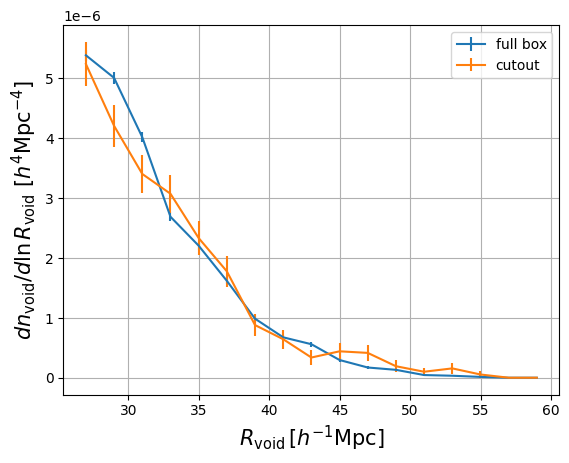

In [9]:
print(f'        True        | Estimated\nVolume: {cutout_vol_true} | {sv.volume}')

sv.plot_size_function(ax=vsf_ax, legend=True, grid=True, label='cutout')
display(vsf_ax.figure)

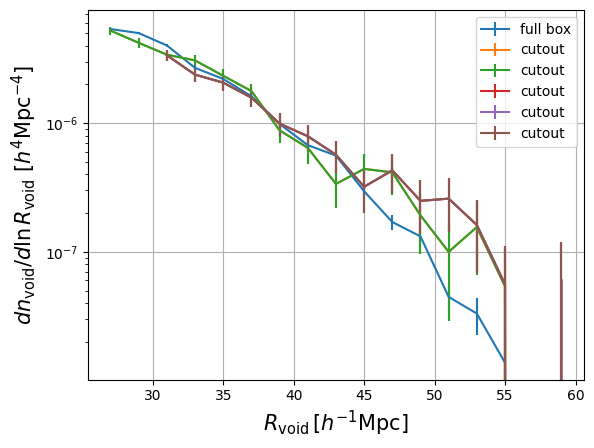

In [11]:
vsf_ax = sv.plot_size_function(ax=vsf_ax, legend=True, grid=True, label='cutout')
sv.size_function = np.load('/home/ntbfin/Downloads/cutout_nR_vsf.npy')
sv.plot_size_function(ax=vsf_ax, legend=True, grid=True, label='cutout')
display(vsf_ax.figure)

# Add observational weights (e.g. varying number density)

Generate a synthetic number density profile.

In [4]:
def prob(x, L, x_slope=0.5):
    x_weighted = np.ones(len(x))
    m = 1 / L / (x_slope - 1)
    C = 1 / (1 - x_slope)
    x_weighted[x > L* x_slope] = m * x[x > L * x_slope] + C
    return x_weighted

Text(0.5, 0, 'Y [$h^{-1}$ Mpc]')

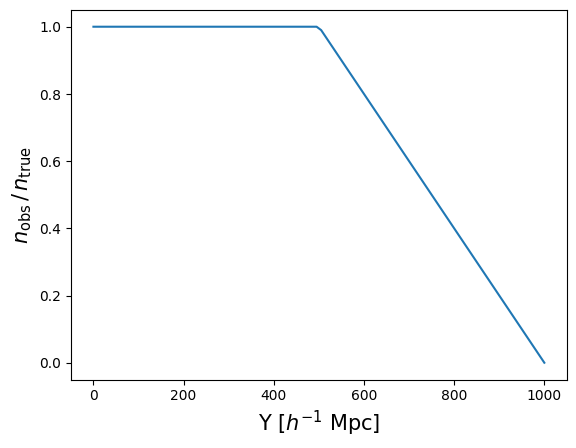

In [5]:
x = np.linspace(0, L, 100)
plt.plot(x, prob(x, L))
plt.ylabel(r'$n_{\rm obs} \,/\, n_{\rm true}$', fontsize=15)
plt.xlabel('Y [$h^{-1}$ Mpc]', fontsize=15)

Subsample data according to profile.

In [6]:
weights = prob(pos_small[:,1], L)
N_samp = weights.sum()
weights /= N_samp
subsample = np.random.choice(range(len(pos_small)), replace=False, size=int(N_samp), p=weights)
pos_nr = pos_small[subsample]

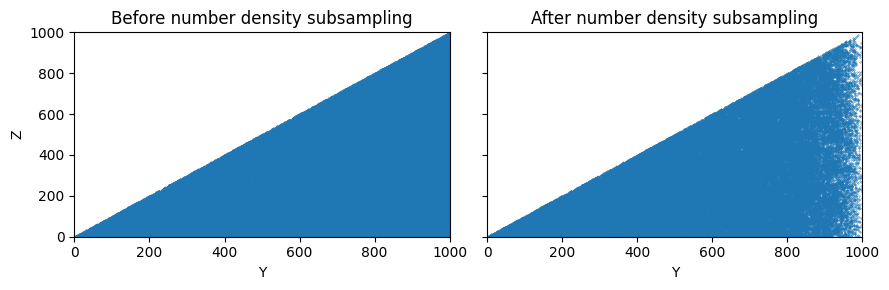

In [7]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(9,3), sharey=True)
ax1.scatter(pos_small[:,1], pos_small[:,2], s=0.1)
ax2.scatter(pos_nr[:,1], pos_nr[:,2], s=0.1)
ax1.set_ylabel('Z')
ax1.set_xlabel('Y')
ax2.set_xlabel('Y')
ax1.set_xlim(0, L)
ax1.set_ylim(0, L)
ax2.set_xlim(0, L)
ax2.set_ylim(0, L)
ax1.set_title('Before number density subsampling')
ax2.set_title('After number density subsampling')
plt.tight_layout()

Weight the randoms to account for variation in number density.

In [8]:
random_weights = prob(randoms[:,1], L)
del pos_small

Run void-finding on cutout with varying number density.

In [10]:
sv = SphericalVoids(data_positions=pos_nr, 
                    random_positions=randoms,
                    random_weights=random_weights,
                    cellsize=cellsize)
sv.run_voidfinding()

16:21:37 | INFO | meshbuilder.py | __init__ | Ln55 | Loading survey-like data
16:21:37 | INFO | meshbuilder.py | size_mesh | Ln310 | Estimating volume and average galaxy separation (Ngal = 146688)


nmesh 512 [512 512 512]
rho_mean: 0.0002975234220554799 [999.99986225 999.75291903 999.87223674] [512 512 512]
ZEROS 66127700 0.49268975853919983


16:21:52 | INFO | meshbuilder.py | create_mesh | Ln397 | Estimating mesh density (nmesh=[158 158 158])


before final 0.0002975234220554799


16:21:56 | INFO | meshbuilder.py | _set_mesh_density | Ln211 | Applying initial smoothing of R=4.2 Mpc/h to the density field
16:21:56 | INFO | meshbuilder.py | _set_mesh_density | Ln235 | 49x number of randoms used
16:21:56 | INFO | 3930880798.py | <module> | Ln1 | Making k-d trees


rho_mean: 0.00024503452840403704 [1106. 1106. 1106.] [158 158 158]
after final 0.0002975234220554799


16:22:00 | INFO | 3930880798.py | <module> | Ln5 | Running spherical void-finder with 8 threads (delta < -0.80)
16:22:00 | INFO | 3930880798.py | <module> | Ln5 | No cells with delta < -0.80 for R=60.0 Mpc/h


SURVEY TEST VERSION!


16:22:01 | INFO | 3930880798.py | <module> | Ln5 | No cells with delta < -0.80 for R=58.0 Mpc/h
16:22:01 | INFO | 3930880798.py | <module> | Ln5 | No cells with delta < -0.80 for R=56.0 Mpc/h
16:22:01 | INFO | 3930880798.py | <module> | Ln5 | Found 1 voids with radius R=54.0 Mpc/h
16:22:01 | INFO | 3930880798.py | <module> | Ln5 | Found 0 voids with radius R=52.0 Mpc/h
16:22:01 | INFO | 3930880798.py | <module> | Ln5 | Found 0 voids with radius R=50.0 Mpc/h
16:22:01 | INFO | 3930880798.py | <module> | Ln5 | Found 4 voids with radius R=48.0 Mpc/h
16:22:01 | INFO | 3930880798.py | <module> | Ln5 | Found 2 voids with radius R=46.0 Mpc/h
16:22:02 | INFO | 3930880798.py | <module> | Ln5 | Found 5 voids with radius R=44.0 Mpc/h
16:22:02 | INFO | 3930880798.py | <module> | Ln5 | Found 14 voids with radius R=42.0 Mpc/h
16:22:02 | INFO | 3930880798.py | <module> | Ln5 | Found 24 voids with radius R=40.0 Mpc/h
16:22:02 | INFO | 3930880798.py | <module> | Ln5 | Found 42 voids with radius R=38.0 M

In [12]:
np.save('/home/ntbfin/Downloads/cutout_nR_vsf', sv.size_function)

In [ ]:
print(f'        True        | Estimated\nVolume: {cutout_vol_true} | {sv.volume}')

sv.plot_size_function(ax=vsf_ax, legend=True, grid=True, label='cutout + n(R)')
display(vsf_ax.figure)